# ML bacteria
使用Machine Learning对bacteria中finetune数据集进行训练并预测test数据集。
## 1 使用原始数据进行训练预测

In [2]:
import numpy as np

# 载入finetune数据集
X_f = './data/X_finetune.npy'
y_f = './data/y_finetune.npy'
X_train = np.load(X_f)
y_train = np.load(y_f)

X_f = './data/X_test.npy'
y_f = './data/y_test.npy'
X_test = np.load(X_f)
y_test = np.load(y_f)

In [34]:
from sklearn.model_selection import cross_validate  # 导入交叉验证
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [4]:
# 使用SVM模型
svm_clf = SVC(kernel='linear')
# 进行交叉验证并返回每个折中的模型
cv_results = cross_validate(svm_clf, X_train, y_train, cv=5, 
                            return_train_score=True, 
                            return_estimator=True)
cv_results

{'fit_time': array([3.9003644 , 3.8301115 , 3.62118793, 4.32407784, 3.99291801]),
 'score_time': array([1.93202591, 1.8139987 , 1.79720759, 1.92637467, 1.80997205]),
 'estimator': [SVC(kernel='linear'),
  SVC(kernel='linear'),
  SVC(kernel='linear'),
  SVC(kernel='linear'),
  SVC(kernel='linear')],
 'test_score': array([0.895     , 0.92166667, 0.92      , 0.905     , 0.88833333]),
 'train_score': array([1., 1., 1., 1., 1.])}

In [25]:
ts = cv_results['test_score']
print("In train dataset, model accuracy is {:.4f} (+/- {:.4f}) ".format(np.mean(ts), 2* np.std(ts)))

In train dataset, model accuracy is 0.906 (+/- 0.0265) 


In [10]:
# 获取每个折中训练的模型
estimators = cv_results['estimator']
# 找到测试分数最高的模型（通过lambda函数搜索cv_results['test_score']，得到最高得分的index，并返回对应index的estimator)
best_estimator = max(estimators, key=lambda e: cv_results['test_score'][estimators.index(e)])
# 预测测试集
y_pred = best_estimator.predict(X_test)
# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")
classification_report_result = classification_report(y_test, y_pred, digits=3, zero_division=0)
print(classification_report_result)

Accuracy: 0.786
              precision    recall  f1-score   support

         0.0      1.000     0.960     0.980       100
         1.0      0.971     1.000     0.985       100
         2.0      0.471     0.560     0.511       100
         3.0      0.862     1.000     0.926       100
         4.0      0.625     0.600     0.612       100
         5.0      0.990     1.000     0.995       100
         6.0      1.000     0.210     0.347       100
         7.0      0.536     0.750     0.625       100
         8.0      0.534     0.700     0.606       100
         9.0      0.472     0.500     0.485       100
        10.0      0.868     0.920     0.893       100
        11.0      0.303     0.100     0.150       100
        12.0      0.742     0.660     0.698       100
        13.0      1.000     0.810     0.895       100
        14.0      0.858     0.910     0.883       100
        15.0      0.829     0.630     0.716       100
        16.0      0.669     0.870     0.757       100
        17.

In [5]:
from sklearn.metrics import confusion_matrix
# 本项目目录config.py文件中的ORDER变量(序号数组，confusion_matrix作图时使用)与STRAINS变量(菌株名称的字典)
from config import ORDER, STRAINS
from utils import plot_cm

def plot_confusion_matrix(y_test, y_pred):  # 对confusion_matrix作图函数
    label = [STRAINS[i] for i in ORDER]
    cm = confusion_matrix(y_test, y_pred, labels=ORDER)    
    
    # Plot confusion matrix
    plot_cm(cm, label)

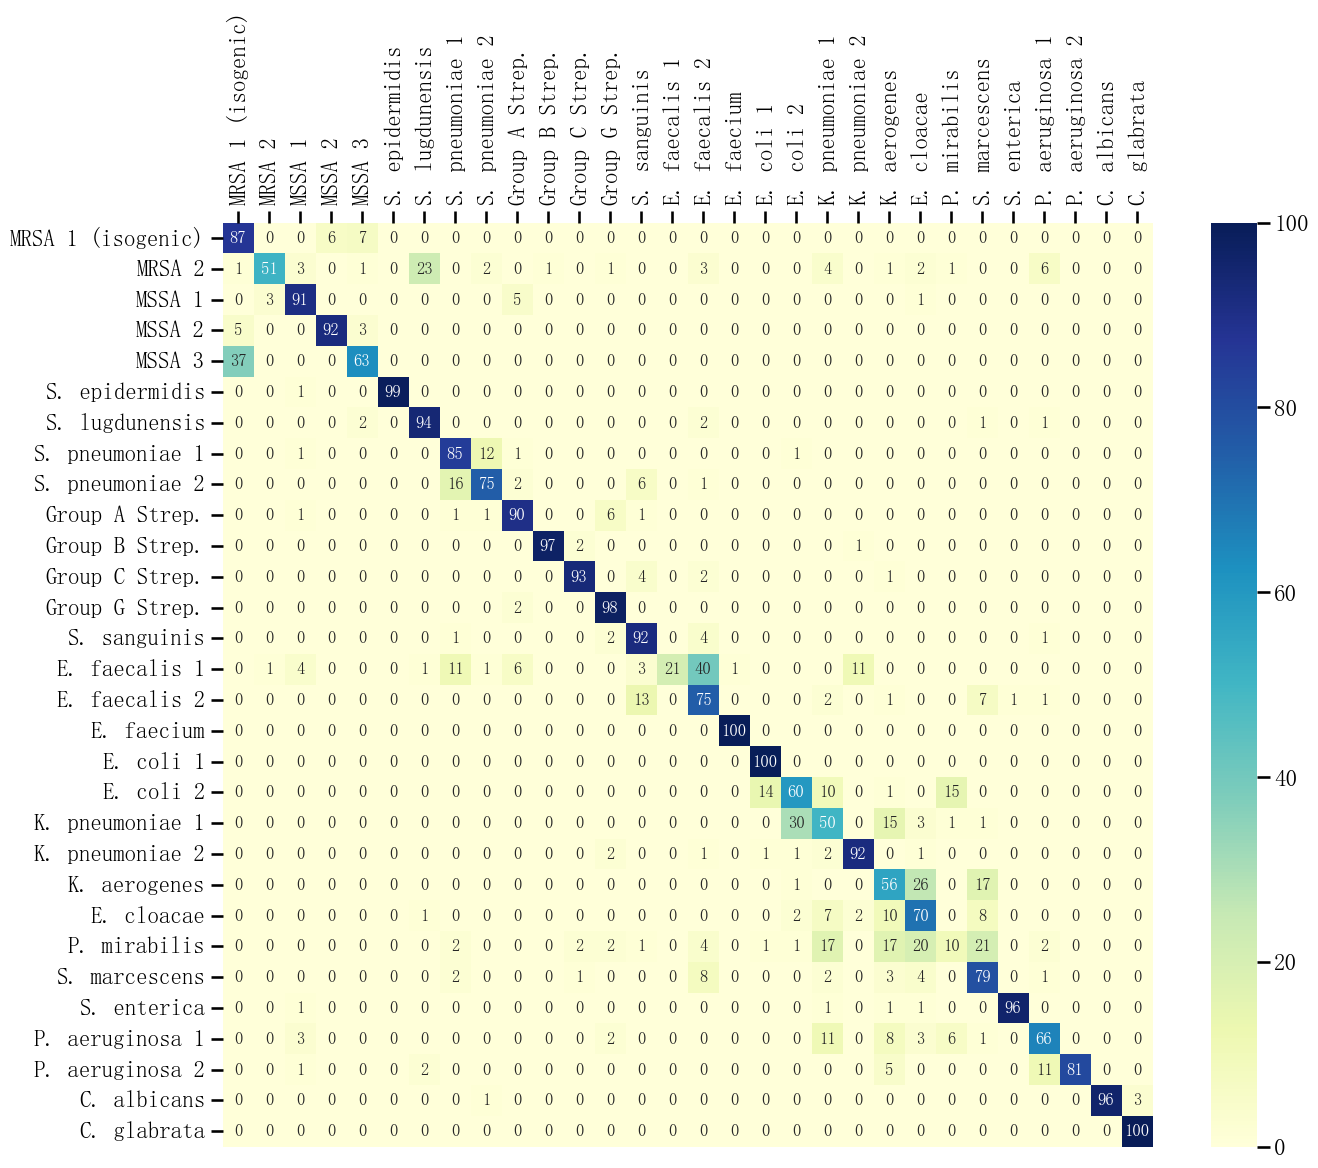

In [8]:
plot_confusion_matrix(y_test, y_pred)  # 预测结果的confusion_matrix图

## 2 使用预处理数据进行训练预测
对train与test数据集进行光滑去噪、基线化后再训练与预测。

In [1]:
from scipy.signal import savgol_filter
from pybaselines import Baseline


def sg_smooth(ys):
    # 定义窗口大小（必须是奇数）
    window_size = 11
    
    # 定义多项式的阶数
    polyorder = 3
    
    # 使用savgol_filter函数计算窗口移动多项式平滑
    ysn = savgol_filter(ys, window_length=window_size, polyorder=polyorder)
    return ysn


def airpls_baseline(ys, x=None):
    # Baseline对象需要x轴坐标, 此时利用ys数组最后一个维度的长度(Feature的个数)生成了一个伪坐标[0, 1, 2, ..., ]
    # (由于Raman中波数基本等间隔，因此这个坐标与实际坐标线性一一映射)
    if x is None:
        x = list(range(ys.shape[-1]))
    baseline_fitter = Baseline(x_data=x) 

    ys_airpls = []
    for y in ys:
        bkg, params = baseline_fitter.airpls(y, lam=1e5) #自适应加权惩罚最小二乘法
        ys_airpls.append(y - bkg)
    return np.array(ys_airpls)

## 2.1 先平滑再基线

In [ ]:
# 对X_train数据进行savgol平滑与airpls降噪
X_train_sg = sg_smooth(X_train)
X_train_airpls = airpls_baseline(X_train_sg)

# 对X_test数据进行savgol平滑与airpls降噪
X_test_sg = sg_smooth(X_test)
X_test_airpls = airpls_baseline(X_test_sg)

In [16]:
from sklearn.model_selection import cross_validate

svm_clf = SVC(kernel='linear')
# 进行交叉验证并返回每个折中的模型
cv_results = cross_validate(svm_clf, X_train_airpls, y_train, cv=5, 
                            return_train_score=True, 
                            return_estimator=True)
cv_results

{'fit_time': array([1.71928596, 1.76044607, 1.58120322, 1.65684748, 1.97198892]),
 'score_time': array([1.99242043, 1.55059171, 1.48696828, 1.44316792, 1.88157701]),
 'estimator': [SVC(kernel='linear'),
  SVC(kernel='linear'),
  SVC(kernel='linear'),
  SVC(kernel='linear'),
  SVC(kernel='linear')],
 'test_score': array([0.91333333, 0.94166667, 0.91666667, 0.93333333, 0.90666667]),
 'train_score': array([1.        , 1.        , 1.        , 1.        , 0.99958333])}

In [27]:
# ts = [0.91333333, 0.94166667, 0.91666667, 0.93333333, 0.90666667]
ts = cv_results['test_score']
print("In train dataset, model accuracy is {:.4f} (+/- {:.4f}) ".format(np.mean(ts), 2* np.std(ts)))

In train dataset, model accuracy is 0.9223 (+/- 0.0261) 


In [17]:
# 获取每个折中训练的模型
estimators = cv_results['estimator']
# 找到测试分数最高的模型
best_estimator = max(estimators, key=lambda e: cv_results['test_score'][estimators.index(e)])
# 预测测试集
y_pred = best_estimator.predict(X_test_airpls)
# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")

classification_report_result = classification_report(y_test, y_pred, digits=3, zero_division=0)
print(classification_report_result)

Accuracy: 0.789
              precision    recall  f1-score   support

         0.0      1.000     0.970     0.985       100
         1.0      0.971     1.000     0.985       100
         2.0      0.470     0.700     0.562       100
         3.0      0.853     0.990     0.917       100
         4.0      0.712     0.520     0.601       100
         5.0      0.971     1.000     0.985       100
         6.0      1.000     0.090     0.165       100
         7.0      0.478     0.760     0.587       100
         8.0      0.657     0.670     0.663       100
         9.0      0.410     0.550     0.470       100
        10.0      0.976     0.800     0.879       100
        11.0      0.353     0.120     0.179       100
        12.0      0.689     0.730     0.709       100
        13.0      0.971     0.680     0.800       100
        14.0      0.916     0.980     0.947       100
        15.0      0.859     0.670     0.753       100
        16.0      0.717     0.910     0.802       100
        17.

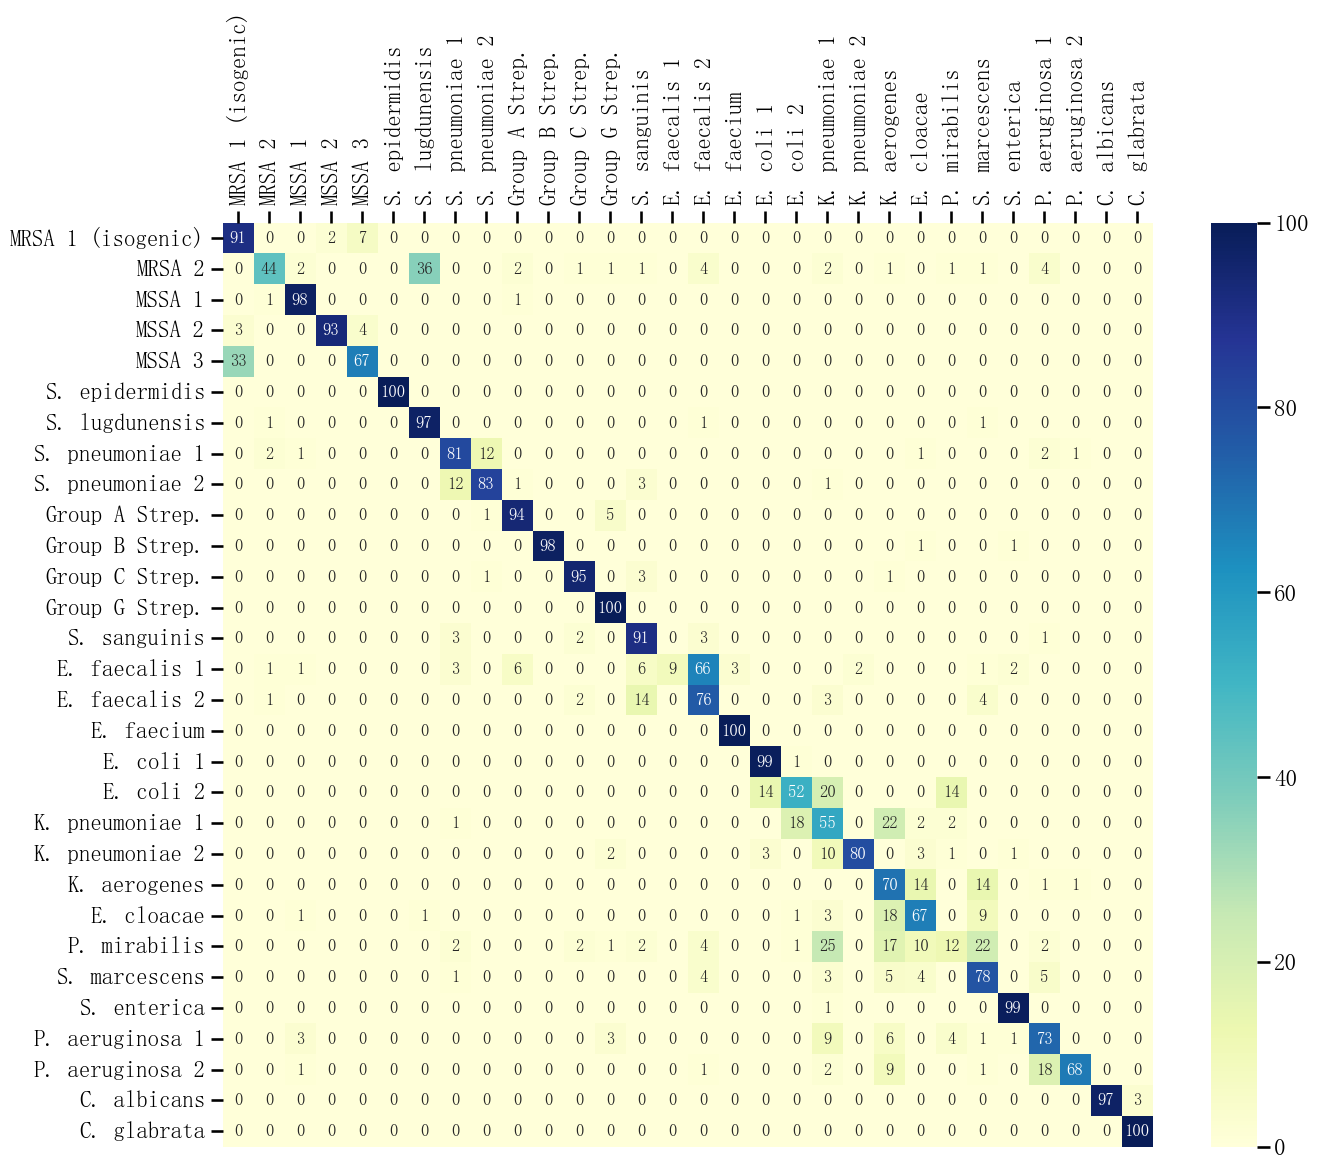

In [18]:
plot_confusion_matrix(y_test, y_pred)

## 2.1 先基线再平滑

In [30]:
X_train_ag = sg_smooth(airpls_baseline(X_train))
X_test_ag = sg_smooth(airpls_baseline(X_test))

from sklearn.model_selection import cross_validate
svm_clf = SVC(kernel='linear')
# 进行交叉验证并返回每个折中的模型
cv_results = cross_validate(svm_clf, X_train_ag, y_train, cv=5, 
                            return_train_score=True, 
                            return_estimator=True)
ts = cv_results['test_score']
print("In train dataset, model accuracy is {:.4f} (+/- {:.4f}) ".format(np.mean(ts), 2* np.std(ts)))

In train dataset, model accuracy is 0.9247 (+/- 0.0332) 


In [31]:
# 获取每个折中训练的模型
estimators = cv_results['estimator']
# 找到测试分数最高的模型
best_estimator = max(estimators, key=lambda e: cv_results['test_score'][estimators.index(e)])
# 预测测试集
y_pred = best_estimator.predict(X_test_ag)
# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")

classification_report_result = classification_report(y_test, y_pred, digits=3, zero_division=0)
print(classification_report_result)

Accuracy: 0.809
              precision    recall  f1-score   support

         0.0      1.000     0.970     0.985       100
         1.0      0.971     1.000     0.985       100
         2.0      0.524     0.770     0.623       100
         3.0      0.884     0.990     0.934       100
         4.0      0.683     0.560     0.615       100
         5.0      0.990     1.000     0.995       100
         6.0      1.000     0.190     0.319       100
         7.0      0.517     0.780     0.622       100
         8.0      0.629     0.660     0.644       100
         9.0      0.474     0.540     0.505       100
        10.0      0.940     0.790     0.859       100
        11.0      0.386     0.170     0.236       100
        12.0      0.708     0.800     0.751       100
        13.0      1.000     0.690     0.817       100
        14.0      0.884     0.990     0.934       100
        15.0      0.851     0.800     0.825       100
        16.0      0.777     0.870     0.821       100
        17.

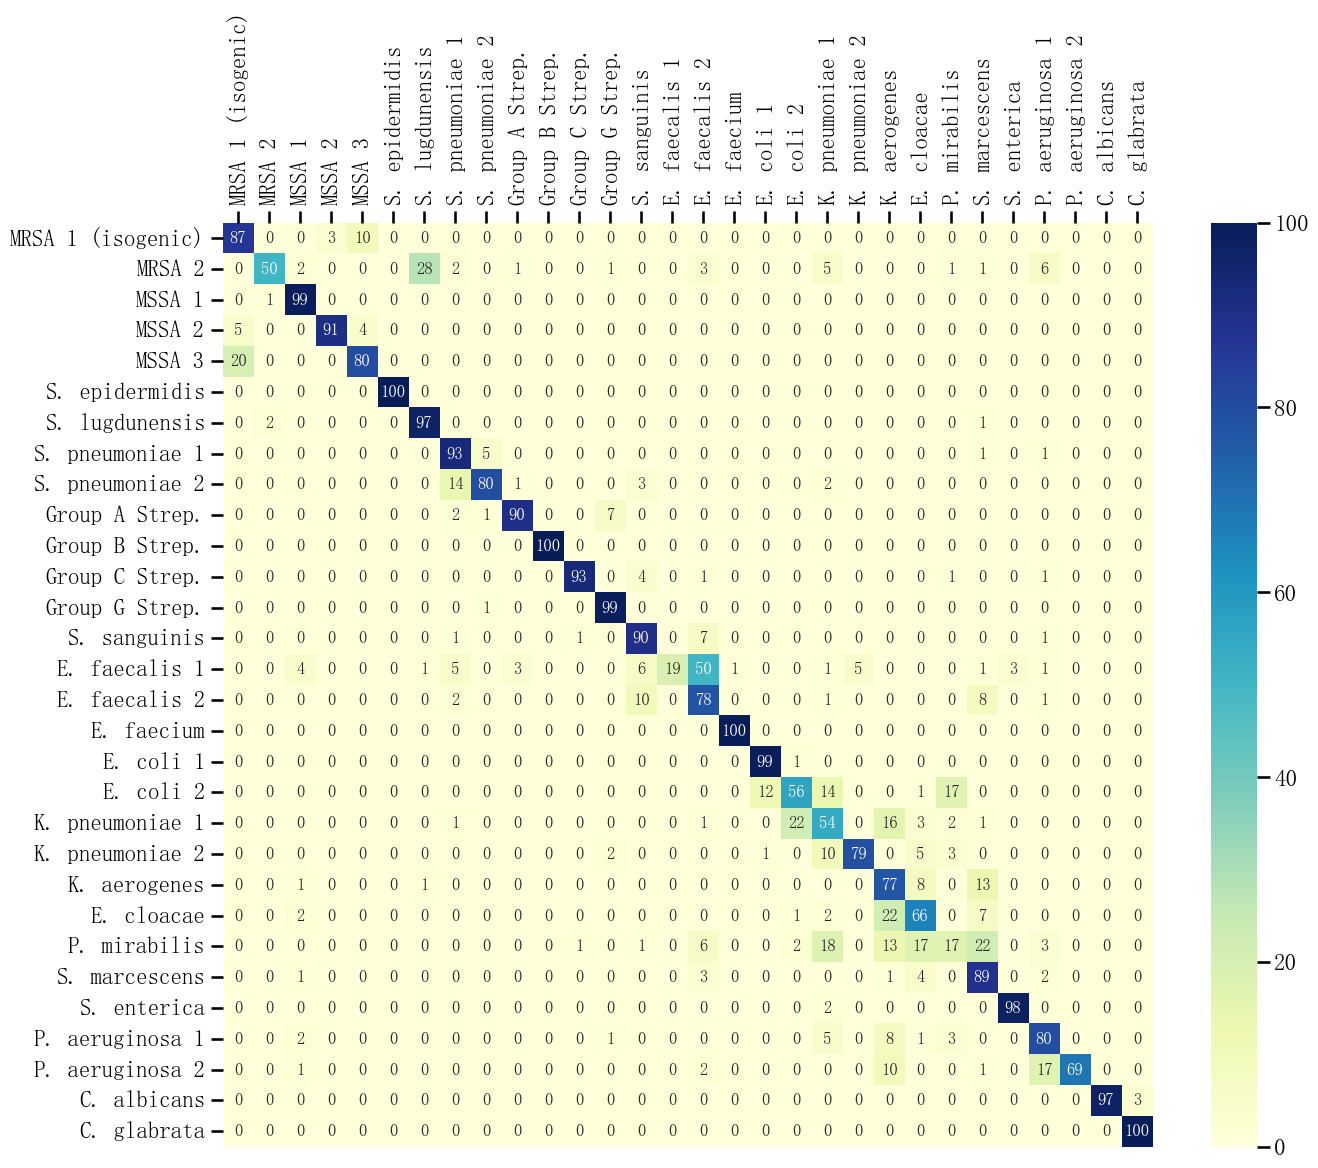

In [33]:
plot_confusion_matrix(y_test, y_pred)

**从结果上来看，先基线化再平滑化，模型效果会更好。实际上一般ML时，无论前面处理时是否做过平滑，在最后再来一次平滑可能效果更好。**

## 3 其他

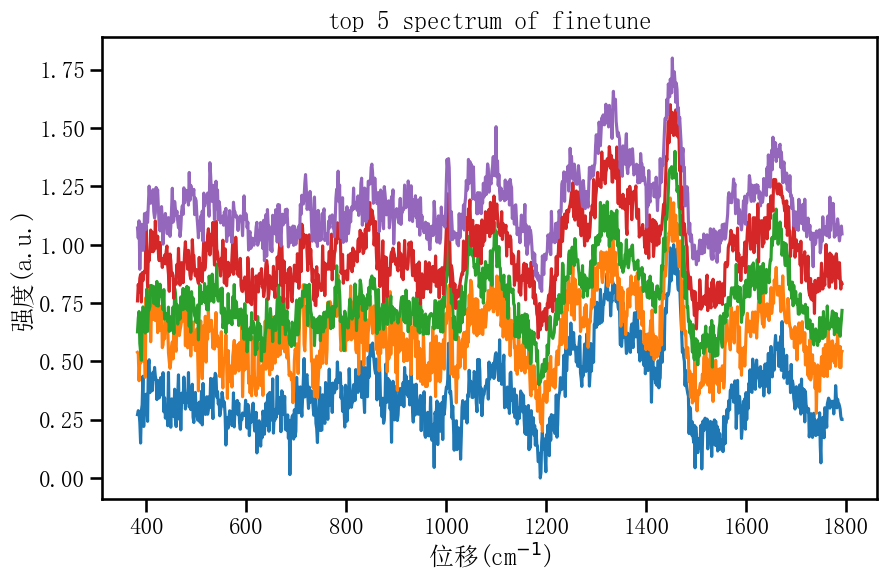

In [11]:
from utils import plot_spectra
x_f = './data/wavenumbers.npy'
x = np.load(x_f)

plot_spectra(x, X_train[:5], 'top 5 spectrum of finetune',  dy=0.2)

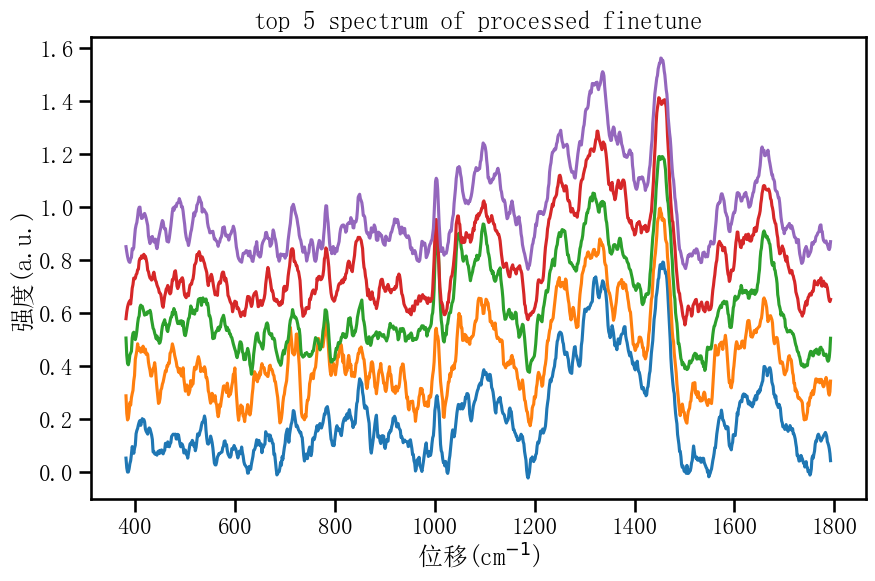

In [13]:
plot_spectra(x, X_train_airpls[:5], 'top 5 spectrum of processed finetune',  dy=0.2)

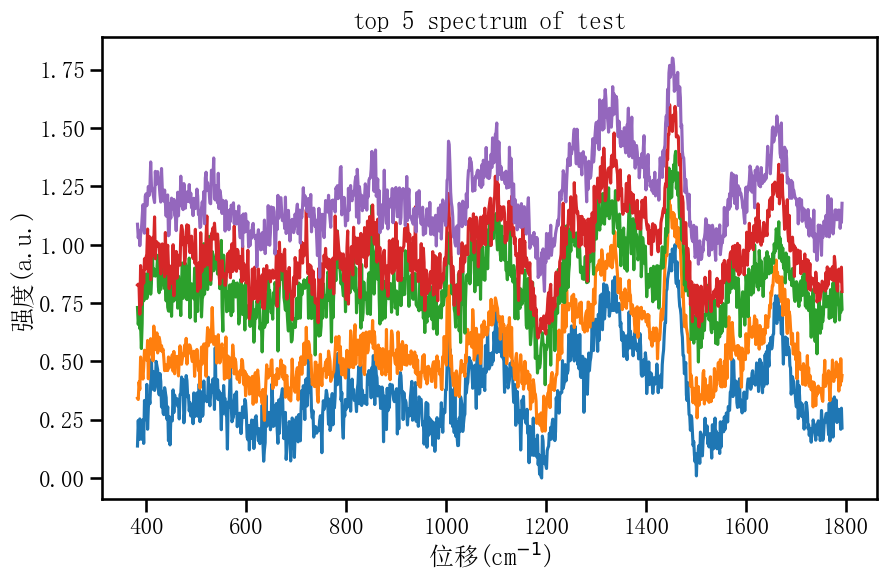

In [14]:
plot_spectra(x, X_test[:5], 'top 5 spectrum of test',  dy=0.2)

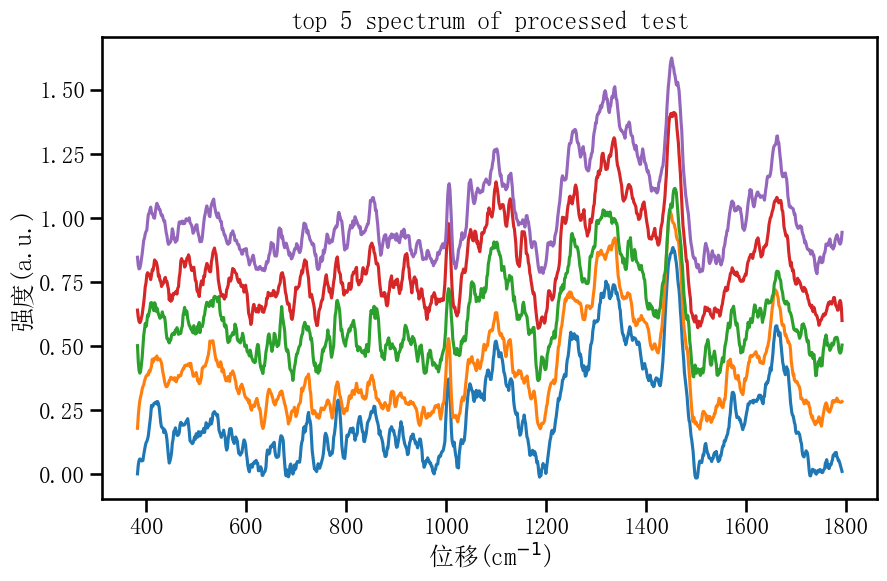

In [15]:
plot_spectra(x, X_test_airpls[:5], 'top 5 spectrum of processed test',  dy=0.2)

# 4 作业
实际上面有许多代码块重复多次，应提取至函数中，这样如果发生修改时只需要修改一处而不需多处修改（多处修改易遗漏且麻烦）。
1) 请把上面重复代码提取到函数方法中，并能使代码可通。(可以先复制本代码文件，并在复制后的文件中修改)
2) 使用其它ML的模型，看能否提升test数据集上的准确率